# Green Industry Practices and Total Factor Productivity

**Data:** Indonesian Manufacturing Firms (IBS 2021)

---
## 0. Import Library

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats.mstats import winsorize
from stargazer.stargazer import Stargazer
import warnings

warnings.filterwarnings('ignore')

---
## 1. Load Data

In [2]:
df = pd.read_stata('ibs_2021.dta')
row_count = len(df)

In [3]:
print(f"Dataset Shape: {df.shape}")
print("\n--- Missingness (columns with missing values) ---")
missing = df.isnull().sum()
print(missing[missing > 0])

expected_cols = ['YPRVCU','LTLNOU','V1115','RDNVCU','RIMVCU','GREEN','YGREEN',
                 'SNIISO','ECOLAB','DASING','RND','INOV','AUTOAI','DISIC5_3','DPROVI']
missing_cols = [c for c in expected_cols if c not in df.columns]
print("\nMissing expected cols:", missing_cols if missing_cols else "None")

Dataset Shape: (30788, 732)

--- Missingness (columns with missing values) ---
DDMSTK      30788
DPUSAT      30788
DPEMDA      30788
LFANOU      30788
LPRNOU      14169
            ...  
ESDLIU      15839
ESDVCU      15843
ESDLIE      16248
ESDVCE      16249
year_cek    30788
Length: 526, dtype: int64

Missing expected cols: None


---
## 2. Data Cleaning

### 2.1 Recode Dummies

In [4]:
# SNIISO: 3=Yes, 4=No (per IBS questionnaire)
if 'SNIISO' in df.columns:
    df['SNIISO'] = np.select([df['SNIISO'] == 3, df['SNIISO'] == 4], [1, 0], default=np.nan)

# DASING is a foreign-ownership percentage; binarize to >0
if 'DASING' in df.columns:
    df['DASING'] = np.where(df['DASING'] > 0, 1, 0)

# Standard 1=Yes, 2=No variables
for col in ['GREEN','YGREEN','ECOLAB','RND','INOV','AUTOAI']:
    if col in df.columns:
        counts = df[col].value_counts().to_dict()
        if 3 in counts:
            print(f"Notice: {col} has 'Don't Know' (code 3) in {counts[3]} rows -> NaN.")
        df[col] = np.select([df[col] == 1, df[col] == 2], [1, 0], default=np.nan)

### 2.2 Document green-module selectivity (IMPORTANT)

The green block (GREEN/YGREEN/SNIISO/ECOLAB) is missing for the *same* set of firms.
These non-respondents are systematically larger. We report this before building the index.

In [5]:
df['has_green'] = df['GREEN'].notna()
print("Green module present:", int(df['has_green'].sum()), "of", len(df))
print("\nMedian workers  | has green:", df.loc[df['has_green'],'LTLNOU'].median(),
      "| no green:", df.loc[~df['has_green'],'LTLNOU'].median())
# Note: firms without the green module are ~2x larger by employment.
# We therefore restrict analysis to green-module respondents and flag the
# external-validity limitation in the paper. We do NOT impute missing=0.

Green module present: 16619 of 30788

Median workers  | has green: 41.0 | no green: 85.0


### 2.3 Build Green Index (cert = SNIISO OR ECOLAB)

In [6]:
# Both cert components are missing together, so max() is safe here.
df['Green_Cert'] = df[['SNIISO','ECOLAB']].max(axis=1)
df['GreenIndex'] = df['GREEN'] + df['YGREEN'] + df['Green_Cert']

### 2.4 Value Added

In [7]:
if 'R1004' in df.columns and df['R1004'].notna().any():
    df['VA'] = pd.to_numeric(df['R1004'], errors='coerce')
elif 'VTLVCU' in df.columns:
    df['VA'] = pd.to_numeric(df['VTLVCU'], errors='coerce')
else:
    df['VA'] = pd.to_numeric(df['YPRVCU'], errors='coerce') - (
        pd.to_numeric(df['RDNVCU'], errors='coerce').fillna(0)
        + pd.to_numeric(df['RIMVCU'], errors='coerce').fillna(0))

for c in ['YPRVCU','LTLNOU','V1115','RDNVCU','RIMVCU','VA']:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

### 2.5 Drop non-positive values (logs undefined ≤ 0)

In [8]:
df['M_total'] = df['RDNVCU'].fillna(0) + df['RIMVCU'].fillna(0)
cond_positive = (
    (df['YPRVCU'] > 0) & (df['VA'] > 0) & (df['LTLNOU'] > 0)
    & (df['V1115'] > 0) & (df['M_total'] > 0)
)
df_clean = df[cond_positive].copy()
print(f"Dropped {row_count - len(df_clean)} rows (non-positive Y/VA/L/K/M). Remaining: {len(df_clean)}")
if df_clean.empty:
    raise ValueError("No valid observations after positivity filter.")

Dropped 16165 rows (non-positive Y/VA/L/K/M). Remaining: 14623


### 2.6 Log Transformations

In [9]:
df_clean['ln_Y']  = np.log(df_clean['YPRVCU'])
df_clean['ln_VA'] = np.log(df_clean['VA'])
df_clean['ln_L']  = np.log(df_clean['LTLNOU'])
df_clean['ln_K']  = np.log(df_clean['V1115'])
df_clean['ln_M']  = np.log(df_clean['M_total'])

### 2.7 Winsorize logs (1st/99th pct)

*Note: winsorizing on the log scale, before TFP estimation. Documented as a limitation.*

In [10]:
for col in ['ln_Y','ln_VA','ln_L','ln_K','ln_M']:
    df_clean[col] = winsorize(df_clean[col], limits=[0.01, 0.01])

### 2.8 Industry code (2-digit from DISIC5_3) and final regression sample

In [11]:
# DISIC5_3 is the populated 5-digit ISIC field
df_clean['industry'] = df_clean['DISIC5_3'].astype(str).str.strip().str[:2]
df_clean = df_clean[df_clean['industry'].str.match(r'\d{2}')].copy()

reg_vars = ['ln_Y','ln_VA','ln_L','ln_K','ln_M','GreenIndex','GREEN','YGREEN',
            'Green_Cert','DASING','RND','INOV','AUTOAI','industry','DPROVI']
df_reg = df_clean.dropna(subset=reg_vars).copy()
print(f"Final regression sample: {len(df_reg):,} firms | "
      f"{df_reg['industry'].nunique()} industries | {df_reg['DPROVI'].nunique()} provinces")

Final regression sample: 10,573 firms | 24 industries | 34 provinces


---
## 3. Stage 1: TFP Estimation (Solow residuals)

**Main = gross output** (returns to scale ≈ 1.11, plausible). Value-added kept as robustness.

In [12]:
# MAIN: Gross output
mod_y = smf.ols('ln_Y ~ ln_L + ln_K + ln_M', data=df_reg).fit()
df_reg['TFP_Y'] = mod_y.resid
print("--- MAIN: Gross Output ---")
print(f"L={mod_y.params['ln_L']:.3f}  K={mod_y.params['ln_K']:.3f}  "
      f"M={mod_y.params['ln_M']:.3f}  RTS={mod_y.params[['ln_L','ln_K','ln_M']].sum():.3f}")

# ROBUSTNESS: Value added (note the implausibly high labor elasticity -> transmission bias)
mod_va = smf.ols('ln_VA ~ ln_L + ln_K', data=df_reg).fit()
df_reg['TFP_VA'] = mod_va.resid
print("\n--- ROBUSTNESS: Value Added ---")
print(f"L={mod_va.params['ln_L']:.3f}  K={mod_va.params['ln_K']:.3f}  "
      f"RTS={mod_va.params[['ln_L','ln_K']].sum():.3f}")
print("NOTE: L≈0.97 and RTS≈1.27 are symptoms of transmission bias (see paper §6).")

--- MAIN: Gross Output ---
L=0.370  K=0.125  M=0.610  RTS=1.106

--- ROBUSTNESS: Value Added ---
L=0.971  K=0.298  RTS=1.269
NOTE: L≈0.97 and RTS≈1.27 are symptoms of transmission bias (see paper §6).


---
## 4. Stage 2: Green–TFP Link

Industry-clustered SE. Industry + province FE. Main uses gross-output TFP.

In [13]:
controls = "DASING + RND + INOV + AUTOAI + C(industry) + C(DPROVI)"
cluster_kw = {"groups": df_reg["industry"]}

def fit_cl(formula):
    return smf.ols(formula, data=df_reg).fit(cov_type="cluster", cov_kwds=cluster_kw)

# (1) MAIN: gross-output TFP on Green Index
model_main = fit_cl(f"TFP_Y ~ GreenIndex + {controls}")
# (2) ROBUSTNESS: value-added TFP on Green Index
model_rob  = fit_cl(f"TFP_VA ~ GreenIndex + {controls}")
# (3) COMPONENTS: gross-output TFP on separate components
model_comp = fit_cl(f"TFP_Y ~ GREEN + YGREEN + Green_Cert + {controls}")

stargazer = Stargazer([model_main, model_rob, model_comp])
stargazer.title("Stage 2: Green Practices and TFP")
stargazer.custom_columns(
    ["Gross-Output TFP (Index)", "VA TFP (Index)", "Gross-Output TFP (Components)"], [1,1,1])
stargazer.covariate_order(
    ['GreenIndex','GREEN','YGREEN','Green_Cert','DASING','RND','INOV','AUTOAI','Intercept'])
stargazer.add_line('2-Digit Industry FE', ['Yes','Yes','Yes'])
stargazer.add_line('Province FE', ['Yes','Yes','Yes'])
stargazer.add_line('SE clustered by industry', ['Yes','Yes','Yes'])
stargazer.significant_digits(3)
display(stargazer)
with open("Stage2_Regression_Results.html","w") as f:
    f.write(stargazer.render_html())

---
## 5. EDA / Descriptives

In [14]:
cols = ['YPRVCU','VA','LTLNOU','V1115','M_total','TFP_Y','TFP_VA','GreenIndex',
        'GREEN','YGREEN','Green_Cert','DASING','RND','INOV','AUTOAI']
display(df_reg[cols].describe().T[['mean','std','min','max','count']])
print("\nGreen Index distribution:")
print(df_reg['GreenIndex'].value_counts().sort_index())
print("\nMean Gross-Output TFP by Green Index:")
print(df_reg.groupby('GreenIndex')['TFP_Y'].mean())

,mean,std,min,max,count
YPRVCU,1.407808e+08,1.088638e+09,4680.000000,6.882000e+10,10573.0
VA,6.124893e+07,5.131999e+08,3035.000000,2.372740e+10,10573.0
LTLNOU,1.744069e+02,7.995029e+02,1.000000,5.074300e+04,10573.0
V1115,5.929111e+08,7.154130e+09,267.000000,2.031860e+11,10573.0
M_total,7.888643e+07,6.798227e+08,1.000000,4.474178e+10,10573.0
TFP_Y,-1.809119e-15,7.213514e-01,-6.327407,6.904149e+00,10573.0
TFP_VA,2.037610e-15,1.140296e+00,-6.246712,8.206603e+00,10573.0
GreenIndex,1.525962e+00,1.052092e+00,0.000000,3.000000e+00,10573.0
GREEN,6.603613e-01,4.736090e-01,0.000000,1.000000e+00,10573.0
YGREEN,6.095716e-01,4.878694e-01,0.000000,1.000000e+00,10573.0



Green Index distribution:
GreenIndex
0.0    2709
1.0    1418
2.0    4622
3.0    1824
Name: count, dtype: int64

Mean Gross-Output TFP by Green Index:
GreenIndex
0.0   -0.022680
1.0    0.061386
2.0   -0.024599
3.0    0.048295
Name: TFP_Y, dtype: float64


---
## 6. Figures (Data & Methods section)
### Figure 1: Sample composition

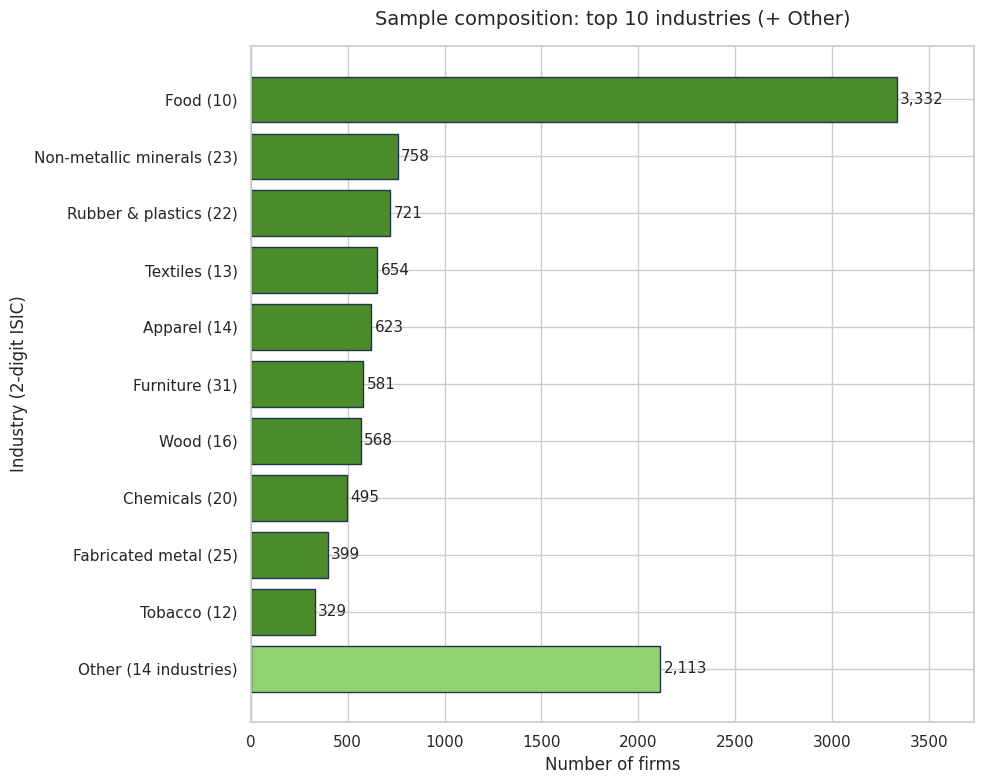

In [15]:
sns.set_theme(style="whitegrid")
kbli = {'10':'Food','11':'Beverages','12':'Tobacco','13':'Textiles','14':'Apparel','15':'Leather',
        '16':'Wood','17':'Paper','18':'Printing','19':'Petroleum','20':'Chemicals','21':'Pharmaceuticals',
        '22':'Rubber & plastics','23':'Non-metallic minerals','24':'Basic metals','25':'Fabricated metal',
        '26':'Electronics','27':'Electrical equipment','28':'Machinery','29':'Motor vehicles',
        '30':'Other transport equip.','31':'Furniture','32':'Other manufacturing','33':'Repair & install.'}
ic = df_reg['industry'].value_counts().sort_values(ascending=False)
top = ic.head(10); other = int(ic.iloc[10:].sum()); other_n = len(ic)-10
labels=[f"{kbli.get(c,c)} ({c})" for c in top.index]; vals=[int(v) for v in top.values]; cols=['#4C8C2B']*len(top)
if other>0: labels.append(f"Other ({other_n} industries)"); vals.append(other); cols.append('#92d171')
plt.figure(figsize=(10,8)); y=np.arange(len(labels))
plt.barh(y,vals,color=cols,edgecolor='#1f3552'); plt.yticks(y,labels); plt.gca().invert_yaxis()
plt.title('Sample composition: top 10 industries (+ Other)',fontsize=14,pad=15)
plt.xlabel('Number of firms'); plt.ylabel('Industry (2-digit ISIC)')
mx=max(vals)
for i,v in enumerate(vals): plt.text(v+mx*0.005,i,f"{v:,}",va='center',fontsize=11)
plt.xlim(0,mx*1.12); plt.tight_layout()
plt.savefig('EDA_1_Industry_Distribution.png',dpi=300); plt.show()

### Figure 2: Green adoption rate (green-module respondents only)

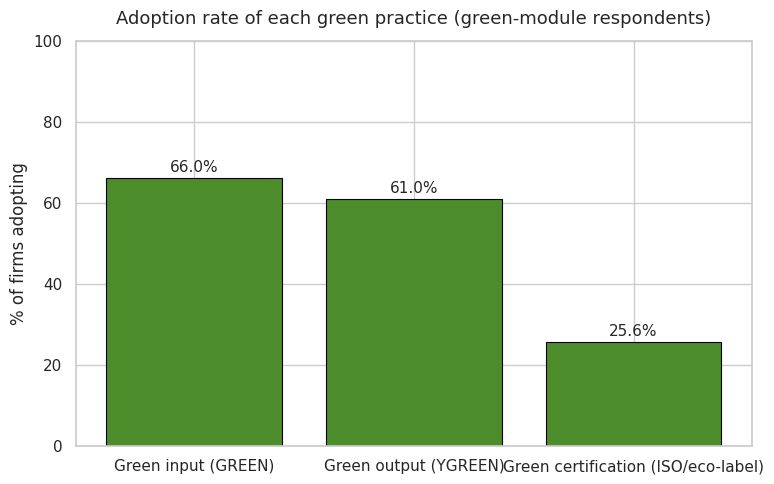

                           Practice      Rate
                Green input (GREEN) 66.036130
              Green output (YGREEN) 60.957155
Green certification (ISO/eco-label) 25.602951


In [16]:
adopt = pd.DataFrame({
    'Practice':['Green input (GREEN)','Green output (YGREEN)','Green certification (ISO/eco-label)'],
    'Rate':[100*df_reg['GREEN'].mean(),100*df_reg['YGREEN'].mean(),100*df_reg['Green_Cert'].mean()]})
plt.figure(figsize=(8,5))
bars=plt.bar(adopt['Practice'],adopt['Rate'],color='#4C8C2B',edgecolor='black',linewidth=0.8)
plt.title('Adoption rate of each green practice (green-module respondents)',fontsize=13,pad=12)
plt.ylabel('% of firms adopting'); plt.ylim(0,100)
for b,v in zip(bars,adopt['Rate']): plt.text(b.get_x()+b.get_width()/2,v+1.5,f"{v:.1f}%",ha='center',fontsize=11)
plt.tight_layout(); plt.savefig('EDA_2_Green_Adoption_Rate.png',dpi=300); plt.show()
print(adopt.to_string(index=False))

# COMPLETED